# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# CNN Model Building - Simple CNN

This project will do process of building various CNN models. We will build 3 CNN architecture with different complexity and compare the performance. For this notebook we will do simple CNN model architecture.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Using CPU")

2026-01-31 18:18:49.392921: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU


## 1. Configuration & Setup

In [2]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
VAL_DIR = PROCESSED_DIR / 'val'
TEST_DIR = PROCESSED_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 100
NUM_CLASSES = 12

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Image size: (224, 224)
Batch size: 16
Epochs: 100


## 2. Data Generators with Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 8424 images belonging to 12 classes.
Found 1550 images belonging to 12 classes.
Found 1556 images belonging to 12 classes.
Train samples: 8424
Validation samples: 1550
Test samples: 1556


# 3. Build model architecture

For this simple CNN architecture we will build CNN with 3 convolutional blocks and ~2M parameters

In [4]:
def create_simple_cnn(input_shape=(224, 224, 3), num_classes=12):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='SimpleCNN')
    
    return model

model = create_simple_cnn()
model.summary()

I0000 00:00:1769858376.656798    1614 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,788,620 (98.38 MB)

 Trainable params: 25,787,660 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Training Configuration

In [5]:
def get_callbacks(model_name):
    model_path = MODELS_DIR / f'{model_name}_best.keras'
    
    callbacks_list = [
        callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callbacks_list

print("Callbacks:")
print("- ModelCheckpoint to save the best model based on val_accuracy")
print("- ReduceLROnPlateau to reduce Learning Rate by 0.5 if val_loss doesn't improve for 5 epochs")

Callbacks:
- ModelCheckpoint to save the best model based on val_accuracy
- ReduceLROnPlateau to reduce Learning Rate by 0.5 if val_loss doesn't improve for 5 epochs


## 7. Training model

In [6]:
print("Training Simple CNN")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('simple_cnn'),
    verbose=1
)

print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Training Simple CNN
Started at: 2026-01-31 18:19:38
Epoch 1/100


2026-01-31 18:19:41.274497: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ed21c007380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-31 18:19:41.274531: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-01-31 18:19:41.415036: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-31 18:19:41.919220: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


  2/527 ━━━━━━━━━━━━━━━━━━━━ 45s 87ms/step - accuracy: 0.2500 - loss: 3.1924   

I0000 00:00:1769858391.342130    2178 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.2974 - loss: 2.4670
Epoch 1: val_accuracy improved from None to 0.23161, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/simple_cnn_best.keras
527/527 ━━━━━━━━━━━━━━━━━━━━ 188s 333ms/step - accuracy: 0.3552 - loss: 2.1565 - val_accuracy: 0.2316 - val_loss: 2.7724 - learning_rate: 0.0010
Epoch 2/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4337 - loss: 1.7753
Epoch 2: val_accuracy improved from 0.23161 to 0.53226, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/simple_cnn_best.keras
527/527 ━━━━━━━━━━━━━━━━━━━━ 83s 158ms/step - accuracy: 0.4040 - loss: 1.8534 - val_accuracy: 0.5323 - val_loss: 1.4505 - learning_rate: 0.0010
Epoch 3/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4349 - loss: 1.7142
Epoch 3: val_accuracy did not improve from 0.53226
527/527 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.4570 - loss: 1.6494 - val_accuracy: 

# 8. Training history plot

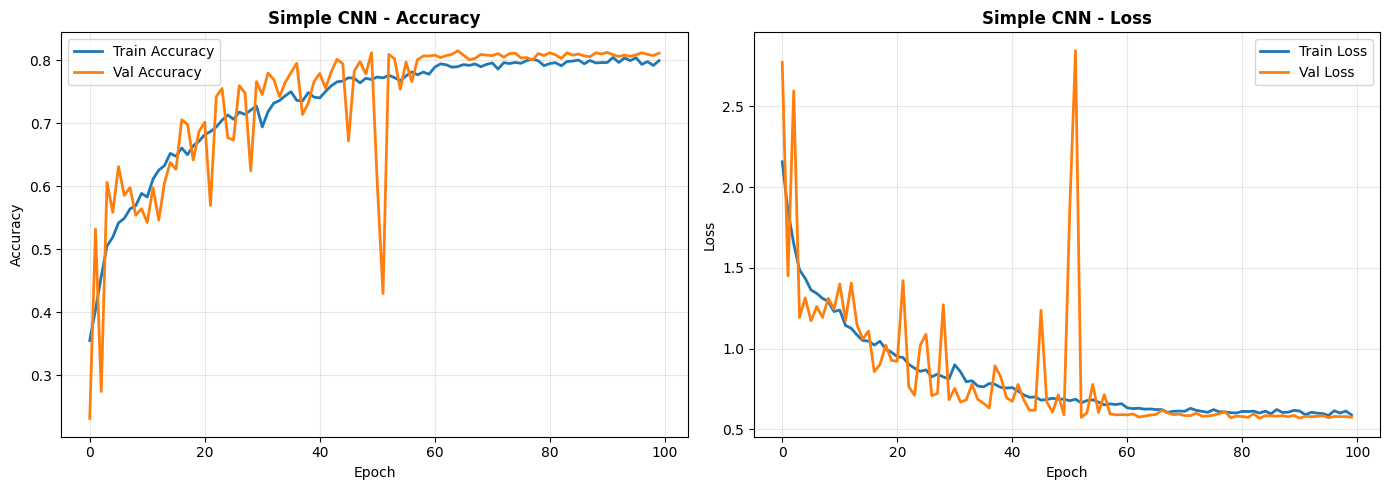

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Simple CNN - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Simple CNN - Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'simple_cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Save model and classification report

In [8]:
model.load_weights(str(MODELS_DIR / 'simple_cnn_best.keras'))

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print(f"\nSimple CNN Test Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(report)

98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step

Simple CNN Test Accuracy: 0.8033

Classification Report:
              precision    recall  f1-score   support

     battery     0.7900    0.8316    0.8103        95
  biological     0.8295    0.7374    0.7807        99
 brown-glass     0.8947    0.8361    0.8644        61
   cardboard     0.8144    0.8778    0.8449        90
     clothes     0.9038    0.8818    0.8927       533
 green-glass     0.8710    0.8571    0.8640        63
       metal     0.7778    0.6364    0.7000        77
       paper     0.6364    0.9333    0.7568       105
     plastic     0.6512    0.6437    0.6474        87
       shoes     0.7240    0.7020    0.7128       198
       trash     0.8200    0.5857    0.6833        70
 white-glass     0.7011    0.7821    0.7394        78

    accuracy                         0.8033      1556
   macro avg     0.7845    0.7754    0.7747      1556
weighted avg     0.8101    0.8033    0.8031      1556



# 10. Confussion matrix plot

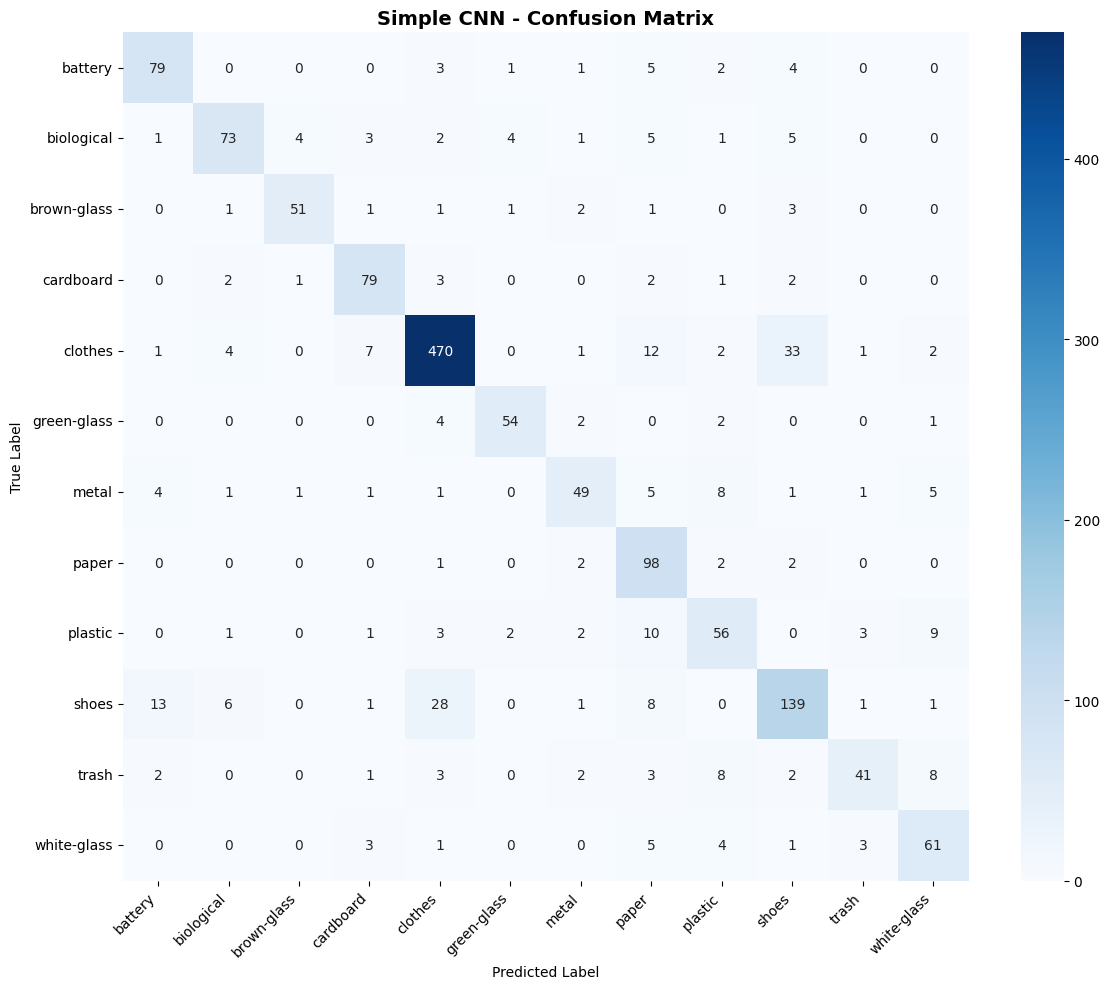

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Simple CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'simple_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Summary

In [10]:
results = {
    'model_name': 'Simple CNN',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'parameters': int(model.count_params()),
    'test_accuracy': float(accuracy),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_train_accuracy': float(history.history['accuracy'][-1]),
    'epochs_trained': len(history.history['accuracy']),
    'configuration': {
        'image_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'max_epochs': EPOCHS
    }
}

with open(MODELS_DIR / 'simple_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to simple_cnn_results.json")
print(f"\nSummary:")
print(f"Parameters: {results['parameters']:,}")
print(f"Test Accuracy: {results['test_accuracy']:.4f}")
print(f"Best Val Accuracy: {results['best_val_accuracy']:.4f}")
print(f"Epochs Trained: {results['epochs_trained']}")

Results saved to simple_cnn_results.json

Summary:
Parameters: 25,788,620
Test Accuracy: 0.8033
Best Val Accuracy: 0.8155
Epochs Trained: 100
